# US Firm Characteristics: Feasibility Analysis

Before building a trading strategy it is worth asking whether the data can support one at all.
This notebook does that and nothing else: it fits no model and makes no forecast.

The strategy being checked is described in `config/setup.yaml`. Once a month it sorts a few
thousand US firms on what is known about them, buys the ones at the top of the sort and sells the
ones at the bottom. That file says which firms are eligible, how often positions change, what a
trade is assumed to cost, and how the history is divided between designing the strategy and
testing it. This notebook checks each of those assumptions against the data and reports what it
finds.

The data is the panel released with Chen, Pelger and Zhu (2020): forty-six measures of each firm,
one row per firm and month. Section A says what those measures are and what makes this particular
release unusual.

## Learning objectives

By the end of this notebook you will be able to:

- Check that a dataset is encoded the way its documentation says it is, rather than taking the
  documentation's word for it
- Describe a universe by how long its members stay in it, and say what that implies about which
  statistics can be computed from it
- Count the cross-section on each date a strategy rebalances, and compare it against the number
  of positions both sides of the book have to fill
- Read off one chart what fraction of monthly moves are larger than the cost of trading them
- Measure how long a firm keeps its place in a ranking, computing the correlation inside each
  firm rather than across the whole panel stacked into one series
- Check that a walk-forward split of the history fits the sample available and leaves the test
  period unread

## Book reference

Chapter 6, Sections 6.2-6.6. This notebook reads the released panel through
`load_firm_characteristics` and `config/setup.yaml`, and writes nothing.

## Prerequisites

None beyond what the sections below define. A reader who has not met a cross-sectional sort or
split a sample for walk-forward evaluation will find both explained where they are first used.

In [1]:
"""US Firm Characteristics Case Study - Feasibility Analysis."""

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from IPython.display import display
from matplotlib.ticker import PercentFormatter

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from case_studies.utils.warning_policy import apply_notebook_warning_policy
from data import load_firm_characteristics
from utils.artifact_specs import resolve_label_horizon
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

apply_notebook_warning_policy()

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
START_DATE = "1990-01-01"
END_DATE = "2016-12-31"
ACF_LAGS = 12

## Configuration

Everything the strategy assumes is declared in `config/setup.yaml`, and this notebook reads those
values rather than repeating them, so the two can never disagree. Four groups of settings matter
here, and each one decides something the sections below test.

**How the history is divided.** The sample runs from 1990 to the end of 2016. The final year is
the *holdout*: a stretch of history that is not looked at while the strategy is being designed, so
that when it is finally evaluated there, the result is not a rehearsal of choices already tuned on
the same data. Everything computed in this notebook uses the earlier part, called the development
period, and `holdout_start` is where the line falls.

**What the strategy trades.** Whatever the release contains. `universe.inclusion_rule` names the
rule the data providers applied, not one this case study invented: a firm-month is in the panel
only if every one of the forty-six measures is available for it. There is no liquidity screen to
apply, because the release carries no prices, no volumes and no share counts to screen on. What
`setup.yaml` does fix is how many positions have to be filled: the sort takes as many as fifty
firms on each side, so at least a hundred have to be present in any month it rebalances.

**What a trade is assumed to cost.** A band rather than a number: `costs.per_leg_cost_bps_range`
gives a low and a high estimate of what one leg costs, as a fraction of the money traded. Doubling
both ends gives the range a round trip pays. Section B.3 draws that range rather than a line,
because a single number would claim a precision this release cannot support.

**What is being predicted.** The return over the next month. Two variants of the same outcome are
also declared - one with extreme returns trimmed, one turned into an up-or-down label - so all
three measure over one month and share a single gap between training and validation data.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = str(SETUP["labels"]["buffer"])
OUTCOME_HORIZON = resolve_label_horizon(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
BREADTH_FLOOR = 2 * max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
LEG_BPS = SETUP["costs"]["per_leg_cost_bps_range"]
ROUND_TRIP_BPS = (2 * LEG_BPS[0], 2 * LEG_BPS[1])
COST_LO, COST_HI = ROUND_TRIP_BPS[0] / 1e4, ROUND_TRIP_BPS[1] / 1e4
TRACKED = {"BEME": "book-to-market", "PROF": "profitability", "r12_2": "momentum"}

print(f"Sample: {START_DATE} to {END_DATE}")
print(f"  Development period, used everywhere below:  {START_DATE} to {HOLDOUT_START}")
print(f"  Holdout, not read by this notebook:         {HOLDOUT_START} to {HOLDOUT_END}")
print(
    f"Universe: whatever the release contains, under its rule "
    f"'{SETUP['universe']['inclusion_rule']}' - a firm-month is present only when every measure is"
)
print(
    f"  Up to {BREADTH_FLOOR // 2} bought and {BREADTH_FLOOR // 2} sold at once, so at least "
    f"{BREADTH_FLOOR} firms must be present in a month for the book to be filled"
)
print(
    f"Assumed cost: {LEG_BPS[0]} to {LEG_BPS[1]} basis points of the money traded per leg, so "
    f"{ROUND_TRIP_BPS[0]} to {ROUND_TRIP_BPS[1]} bps for a round trip"
)
print(
    f"Forecast horizon: {PRIMARY_LABEL}, the return over the coming month, with variants "
    f"{' and '.join(SETUP['labels']['variants'])} resolving at the same horizon"
)

Sample: 1990-01-01 to 2016-12-31
  Development period, used everywhere below:  1990-01-01 to 2016-01-01
  Holdout, not read by this notebook:         2016-01-01 to 2016-12-31
Universe: whatever the release contains, under its rule 'complete_characteristic_case' - a firm-month is present only when every measure is
  Up to 50 bought and 50 sold at once, so at least 100 firms must be present in a month for the book to be filled
Assumed cost: 5 to 20 basis points of the money traded per leg, so 10 to 40 bps for a round trip
Forecast horizon: fwd_ret_1m, the return over the coming month, with variants fwd_ret_1m_win and fwd_class_1m resolving at the same horizon


## A. Orientation

### What a firm characteristic is

A **characteristic** is something measurable about a company that might explain what its shares go
on to do: how cheap it is against the value of what it owns, how profitable it is, how much it has
invested recently, how much its shares have already moved, how much they bounce around, how easily
they trade. Each is computed for every firm, every month, from accounting statements and price
history. This release carries forty-six of them.

The idea a strategy built on them rests on is comparative rather than absolute. Nothing here
claims to say what a company is worth. What the measures support is an ordering: given two firms,
which one looks more like the firms that have tended to do well next month. That is why the
strategy sorts rather than forecasts a price.

### What makes this release unusual

Three things, and each one changes what this notebook can check.

It is **anonymized**. The firms have identifiers rather than names, and an identifier is stable
only inside one published block of the data rather than across the whole release. So a firm cannot
be looked up, matched to a filing, or followed with certainty across the full history.

It carries **no prices**. Every column is either a characteristic or the realized return for the
month. There is no quote, no volume and no share count, which is why the cost of trading has to be
assumed rather than measured, and why the universe cannot be screened for liquidity.

The characteristics are **ranks, not levels**. Rather than publishing a firm's book-to-market
ratio itself, the providers sort every firm on that ratio each month and publish each firm's
position in the sort, rescaled to a fixed interval centred on zero: the lowest-ranked firm sits at
one end, the highest at the other, and the middle firm at zero. Every characteristic therefore has
the same distribution in every month, by construction, and the only information any of them
carries is relative standing. Section B.1 checks that the data really is encoded this way rather
than taking it on trust.

### Why sorting firms against each other is a strategy

The strategy takes no view on the market as a whole. Once a month it sorts the firms on what a
model reads out of the characteristics, buys the top of the sort and sells the bottom. Selling
shares the portfolio does not own means borrowing them and paying a fee to whoever lent them,
which is a cost the bought side does not carry.

Holding both ends is what makes the sort the thing being tested. A book that only bought the top
would rise and fall with the market as much as with the ordering, and the ordering's own
contribution could not be separated out.

### The three questions this notebook asks

1. **Is the cross-section wide enough on the dates the strategy acts?** Positions change monthly,
   and both sides of the book have to be fillable in each month.
2. **Is a typical monthly move worth more than it costs to capture?** The cost is assumed rather
   than measured here, so the question is asked against a range rather than a number.
3. **Is there enough history to evaluate this honestly?** Enough to split into training and
   validation periods several times over, with the holdout left untouched.

## B. Universe and cost feasibility

### B.1 Load the data and look at the universe

The loader returns one row per firm and month, with the realized monthly return in `ret`. The
holdout is cut once, here, so everything below runs on data a design choice is allowed to see.

Three properties are checked before anything is computed. The first two are the ordinary ones:
that the three characteristics carried through the sections below are present, and that no row
reaches into the holdout. The third checks the encoding Section A described - that every one of
the forty-six really does stay inside the interval a rank occupies. That is the check that catches
the mistake worth catching here: a level read as a rank, or a rank read as a level, produces
plausible numbers all the way to the end, and a book-to-market ratio or a profit margin would sit
far outside those bounds on the first row.

In [4]:
window = pl.col("timestamp").is_between(
    pl.lit(START_DATE).str.to_date(), pl.lit(END_DATE).str.to_date(), closed="both"
)
panel = load_firm_characteristics(split="all").filter(window)
research = panel.filter(pl.col("timestamp") < pl.lit(HOLDOUT_START).str.to_date()).sort(
    ["symbol", "timestamp"]
)
CHARACTERISTICS = [c for c in research.columns if c not in ("symbol", "timestamp", "ret", "split")]

In [5]:
values = research.select(CHARACTERISTICS)
lowest = float(values.min().to_numpy().min())
highest = float(values.max().to_numpy().max())
assert not set(TRACKED) - set(research.columns), "a characteristic is absent from the release"
assert research["timestamp"].max() < np.datetime64(HOLDOUT_START), "the frame reaches the holdout"
assert lowest >= -0.5 and highest <= 0.5, "a characteristic falls outside the interval of a rank"
print(
    f"{research['symbol'].n_unique():,} firms, {len(research):,} firm-months, "
    f"{research['timestamp'].n_unique():,} month-ends from {research['timestamp'].min()} to "
    f"{research['timestamp'].max()}\n"
    f"{len(CHARACTERISTICS)} characteristics, every value between {lowest:.2f} and {highest:.2f}"
)

9,793 firms, 780,882 firm-months, 312 month-ends from 1990-01-31 to 2015-12-31
46 characteristics, every value between -0.50 and 0.50


Ten thousand anonymous identifiers are a count, not a description. What a reader needs before
trusting anything computed from this panel is how long a firm stays in it, because two things
below depend on it. A statistic computed inside a firm - Section B.4's - needs firms with enough
history to compute it from. And a universe whose members turn over quickly is one where a strategy
is constantly buying into and out of names, which is what the trading cost in Section B.3 is
charged on.

The table groups firms by how many months they appear in. `share_unbroken` is the fraction of
firms in each group whose months run consecutively with no gap in the middle; a gap matters
because a correlation between a firm's rank this month and its rank "one month later" is not that
at all if the next row is two years further on.

Read the table for where the rows are rather than where the firms are. Most firms are short-lived,
and most of the panel is nonetheless contributed by the long-lived ones.

In [6]:
months = research.select("timestamp").unique().sort("timestamp").with_row_index("month")
indexed = research.join(months, on="timestamp")
tenure_band = (
    pl.when(pl.col("months_present") < 24)
    .then(pl.lit("1. under 2 years"))
    .when(pl.col("months_present") < 60)
    .then(pl.lit("2. 2 to 5 years"))
    .when(pl.col("months_present") < 120)
    .then(pl.lit("3. 5 to 10 years"))
    .otherwise(pl.lit("4. 10 years or more"))
)
by_firm = indexed.group_by("symbol").agg(
    pl.len().alias("months_present"),
    (pl.col("month").max() - pl.col("month").min() + 1).alias("span"),
)
by_firm = by_firm.with_columns((pl.col("months_present") == pl.col("span")).alias("unbroken"))
tenure = (
    by_firm.with_columns(tenure_band.alias("tenure"))
    .group_by("tenure")
    .agg(
        pl.len().alias("firms"),
        pl.col("months_present").sum().alias("firm_months"),
        pl.col("unbroken").mean().round(3).alias("share_unbroken"),
    )
    .with_columns(
        (100 * pl.col("firm_months") / pl.col("firm_months").sum()).round(1).alias("pct_of_rows")
    )
    .sort("tenure")
)
with pl.Config(tbl_rows=tenure.height, tbl_cols=tenure.width):
    display(tenure)

tenure,firms,firm_months,share_unbroken,pct_of_rows
str,u32,u32,f64,f64
"""1. under 2 years""",2102,23224,0.944,3.0
"""2. 2 to 5 years""",3429,108972,0.966,14.0
"""3. 5 to 10 years""",1841,157905,0.892,20.2
"""4. 10 years or more""",2421,490781,0.865,62.8


### B.2 How many firms are available when the strategy trades

A book that buys fifty firms and sells fifty others needs a hundred firms present in the month it
rebalances. What decides whether the strategy is buildable is therefore firms per month, not firms
in the sample: an average over the whole history would hide a stretch where the cross-section was
too thin to fill either side.

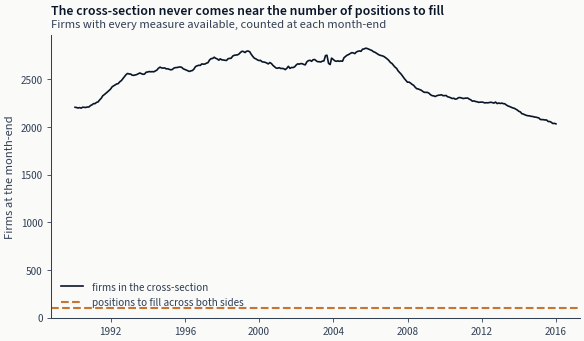

In [7]:
breadth = research.group_by("timestamp").agg(pl.len().alias("n_firms")).sort("timestamp")

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(
    breadth["timestamp"],
    breadth["n_firms"],
    color=COLORS["blue"],
    linewidth=1.2,
    label="firms in the cross-section",
)
ax.axhline(
    BREADTH_FLOOR,
    color=COLORS["copper"],
    ls="--",
    lw=1.5,
    label="positions to fill across both sides",
)
ax.set_ylim(0, None)
ax.set_ylabel("Firms at the month-end")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "The cross-section never comes near the number of positions to fill",
    subtitle="Firms with every measure available, counted at each month-end",
)
show_with_alt(
    fig,
    "Firms carrying every characteristic at each month-end, against the number of positions the long-short book has to fill on both sides.",
)

### B.3 What a round trip costs, and what a move is worth

The release carries no quotes, so a cost per firm cannot be measured from it. `setup.yaml::costs`
declares a range for one leg instead, in **basis points** - one hundredth of one percent - of the
money traded. Both ends are doubled here into the range a round trip pays, and both are drawn,
because collapsing an honest range to its midpoint would claim a precision this release cannot
support.

A long-short sort does not earn the market's return; it earns the difference between the firms it
bought and the firms it sold. So the quantity to compare against cost is not how far the market
moves but how far apart the firms are from each other in a month. The **interdecile range** is one
measure of that: the return of the firm at the 90th percentile minus the return of the firm at the
10th, month by month. If that spread ever approached the round trip, there would be nothing left
to capture after paying for the trade.

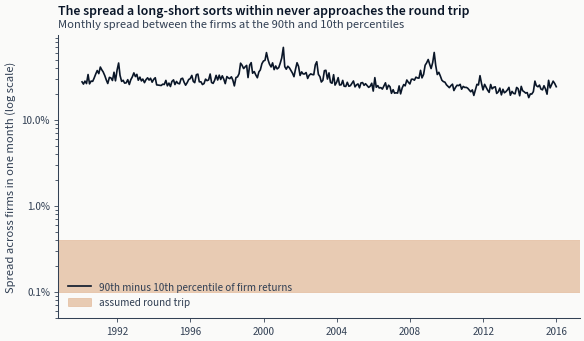

In [8]:
returns = research.select("timestamp", "ret").drop_nulls("ret")
dispersion = (
    returns.group_by("timestamp")
    .agg((pl.col("ret").quantile(0.9) - pl.col("ret").quantile(0.1)).alias("interdecile"))
    .sort("timestamp")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(
    dispersion["timestamp"],
    dispersion["interdecile"],
    color=COLORS["blue"],
    lw=1.2,
    label="90th minus 10th percentile of firm returns",
)
ax.axhspan(COST_LO, COST_HI, color=COLORS["copper"], alpha=0.35, label="assumed round trip")
ax.set_yscale("log")
ax.set_ylim(COST_LO / 2, None)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
ax.set_ylabel("Spread across firms in one month (log scale)")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "The spread a long-short sorts within never approaches the round trip",
    subtitle="Monthly spread between the firms at the 90th and 10th percentiles",
)
show_with_alt(
    fig,
    "Monthly spread between the firms at the 90th and 10th percentiles of return, on a log scale, against the band of assumed round-trip cost.",
)

Two features of that series are worth naming, because both bear on decisions made later. It widens
sharply in market stress, so the opportunity a cross-sectional sort has is largest exactly when
risk is highest. And it has drifted down since the turn of the century: the opportunity narrows
over the sample rather than the cost rising against it.

The chart below asks the cost question directly. It is an **exceedance curve**, and it reads from
the right: pick a move size on the horizontal axis, and the curve gives the fraction of
firm-months that moved at least that far. Where it crosses the cost band is the fraction of
moves larger than the round trip they would have paid.

One thing this chart is not. It is the distribution of how far prices move, ignoring direction. It
is not the return a strategy would earn: nothing here is signed, and nothing decides which side of
a move a position would have been on. Whether the sort can pick that side is the question
Chapter 7 onwards asks. This is only whether the moves are large enough to be worth trying.

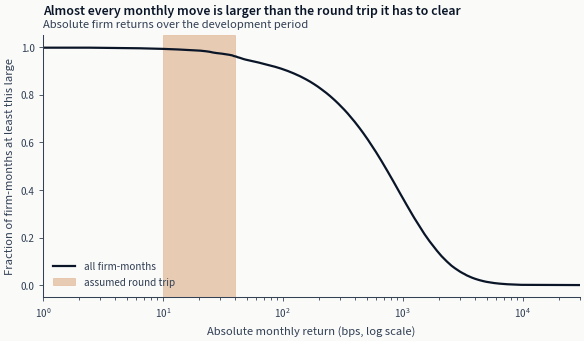

In [9]:
magnitude, fraction = exceedance_curve(returns["ret"].abs().to_numpy())

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(magnitude * 1e4, fraction, color=COLORS["blue"], lw=1.6, label="all firm-months")
ax.axvspan(*ROUND_TRIP_BPS, color=COLORS["copper"], alpha=0.35, label="assumed round trip")
ax.set_xscale("log")
ax.set_xlim(1, 3e4)
ax.set_xlabel("Absolute monthly return (bps, log scale)")
ax.set_ylabel("Fraction of firm-months at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Almost every monthly move is larger than the round trip it has to clear",
    subtitle="Absolute firm returns over the development period",
)
show_with_alt(
    fig,
    "Exceedance curve of absolute monthly firm returns: the fraction of firm-months moving at least a given size, against the assumed round-trip cost band.",
)

### B.4 How long a firm keeps its place in the ranking

Rebalancing every month is only worth the trading it causes if what a characteristic says at one
month-end still says something at the next. Since each characteristic is a position in a sort
rather than a level, the question has a precise form: how fast does a firm's place in that sort
change?

The measurement is an **autocorrelation**: the correlation between a firm's rank in one month and
its rank some number of months later. Plotted against that number of months, it shows how long a
firm holds its place, and the answer differs sharply by what is being ranked, which is the point
of drawing three of them together. Book-to-market and profitability come from accounting
statements that are restated a few times a year. Momentum is a trailing return, and it drops the
oldest month and adds a new one every month, so a firm's place in it can move without anything
about the firm changing.

It is computed inside each firm and then averaged across firms. Stacking thousands of firms into
one long series and correlating that returns a number too, and the number is wrong: at every point
where one firm's history ends and the next begins, it correlates two unrelated companies. Firms
whose months have a gap in the middle are dropped, because a gap makes the row after a month look
like the next month when it is not, and so are firms with too little history for the longest lag
to be estimated from. The band shows how large a correlation could plausibly be if a firm's rank
carried no information about its own past at all.

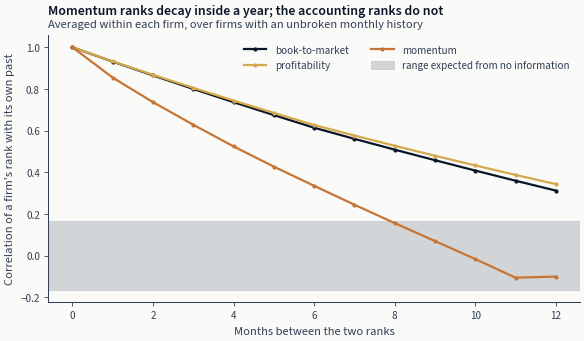

In [10]:
unbroken = by_firm.filter(pl.col("unbroken")).select("symbol")
tracked = indexed.join(unbroken, on="symbol").sort(["symbol", "timestamp"])
acfs = {
    name: panel_acf(tracked, entity_col="symbol", value_col=name, max_lags=ACF_LAGS, min_obs=48)
    for name in TRACKED
}

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
palette = (COLORS["blue"], COLORS["amber"], COLORS["copper"])
for (name, label), color in zip(TRACKED.items(), palette, strict=True):
    acf = acfs[name]
    ax.plot(acf["lag"], acf["acf"], color=color, lw=1.6, marker="o", ms=3, label=label)
band = float(acfs[next(iter(TRACKED))]["band"][0])
ax.axhspan(
    -band, band, color=COLORS["neutral"], alpha=0.2, label="range expected from no information"
)
ax.set_xlabel("Months between the two ranks")
ax.set_ylabel("Correlation of a firm's rank with its own past")
ax.legend(frameon=False, fontsize=8, ncol=2)
add_message_title(
    ax,
    "Momentum ranks decay inside a year; the accounting ranks do not",
    subtitle="Averaged within each firm, over firms with an unbroken monthly history",
)
show_with_alt(
    fig,
    "Autocorrelation of a firm's cross-sectional rank with its own past, by months of lag, for book-to-market, profitability and momentum, against the band expected from no information.",
)

### B.5 Move size against cost

Two numbers summarise what B.3 drew. The first is the median absolute monthly move divided by the
midpoint of the assumed round trip, which says how much larger a typical move is than a typical
cost. The second is the share of moves larger than the upper end of that range, which is the
conservative version of the same question.

Neither says the strategy earns anything. Both count a move down exactly as they count a move up,
and both legs of the round trip are paid whichever way the move went. What they rule out is the
case where the design fails immediately, because a typical move is smaller than the cost of
capturing it.

In [11]:
absolute = returns.select(pl.col("ret").abs().alias("move"))
median_move_bps = float(absolute["move"].median()) * 1e4
clears_cost = float((absolute["move"] > ROUND_TRIP_BPS[1] / 1e4).mean())
print(
    f"Median absolute monthly move {median_move_bps:.0f} bps against a round trip of "
    f"{ROUND_TRIP_BPS[0]} to {ROUND_TRIP_BPS[1]} bps, "
    f"{median_move_bps / np.mean(ROUND_TRIP_BPS):.0f}x the middle of that range\n"
    f"Share of moves larger than the upper end of the range {clears_cost:.3f}"
)

Median absolute monthly move 706 bps against a round trip of 10 to 40 bps, 28x the middle of that range
Share of moves larger than the upper end of the range 0.961


The median absolute monthly move is 706 bps against an assumed round trip of 10 to 40 bps, 28
times the middle of that range, and 0.961 of firm-months move further than its upper end.

## C. Design decisions

The sections above are evidence. This section is where that evidence meets the choices recorded in
`setup.yaml`, and says what each one rests on.

### C.1 How often to rebalance

`setup.yaml::decision.cadence` sorts the firms at the month-end close and trades at the next open.
The release is monthly, so there is no faster schedule available to compare against - the data
fixes the fastest the strategy could possibly be. What Section B.4 shows is that a faster one
would not be worth much anyway: the accounting ranks barely move from one month to the next, so a
book rebalancing more often would mostly be paying to trade the noise in a sort rather than a
change in what the sort says.

The providers refresh the annual accounting variables at the end of June and the monthly ones at
each month-end for the following month, and publish no filing dates, so the notebook cannot check
when each value became knowable. That is a limitation of the release rather than a choice.

### C.2 What would send this design back

A feasibility study is only useful if some result would have stopped it. The one this notebook
could have produced is a cost failure: if a typical monthly move had been smaller than the round
trip needed to capture it, the sort would pay more to trade than the move it is trying to catch.
Section B.5 is that measurement, and Chapter 18 repeats it against the trades a backtest actually
places rather than against raw moves.

The rest are outcomes of the strategy rather than properties of the data, and each is measured
where its evidence exists. Chapter 7 asks whether the ordering has any relationship at all to the
returns that follow it. Chapter 16 asks whether it earns enough per unit of risk to be worth
running once the borrow fee on the sold side is charged. And a result concentrated in the firms
that are hardest to trade would be a result the strategy could not have collected at size - a
question this release cannot answer, because it publishes no measure of how easily a firm's shares
trade in dollars.

### C.3 What the strategy does with the ordering

`setup.yaml::mapping.class` sorts firms on the model's score and holds both ends. Section A gave
the reason: a book that only bought the top would move with the market as much as with the
ordering.

Each firm held gets an equal share of the money inside its side. A weighting optimised for risk
would fold an estimate of how the firms move together into the result, and the ordering's own
contribution could no longer be separated from that estimate's. `setup.yaml` excludes those
weightings here for a second reason as well: they need a history of returns per firm, and an
identifier that is stable only inside one published block does not reliably supply one.

## D. Walk-forward structure

### D.1 How much an evaluation has to spend

Three quarters of a million rows look like a large sample, but a strategy that changes its
positions once a month does not get to treat every row as an independent opportunity. What it
spends is month-ends. A wider cross-section in one month buys precision in what that month says;
it does not buy another month.

In [12]:
print(
    f"Month-ends {research['timestamp'].n_unique():,} | firms {research['symbol'].n_unique():,} | "
    f"firm-months {len(research):,}\n"
    f"Firms per month-end: {breadth['n_firms'].median():,.0f} at the median, "
    f"{breadth['n_firms'].min():,} at the fewest, {breadth['n_firms'].max():,} at the widest"
)

Month-ends 312 | firms 9,793 | firm-months 780,882
Firms per month-end: 2,588 at the median, 2,032 at the fewest, 2,826 at the widest


### D.2 The folds

A model is fitted on one stretch of history and evaluated on the stretch that follows it, then the
pair moves forward and the process repeats. Each fit-then-evaluate pair is a **fold**, and
evaluating this way is called **walk-forward**, because the split always runs in the direction
time does.

Two settings decide where the boundaries fall, and they answer different questions. The gap left
between a training window and the validation window that follows it is called **purging**, and its
width comes from `labels.buffer` in `setup.yaml`: one month here, applying to all three labels.
Separately, `labels.horizons` says how far past its own timestamp a label's outcome is still
unresolved, which is what decides how much of the last validation window has to be given back
before the held-back period opens. On this release those are not the same number. Each row pairs
the characteristics observed at the end of one month with the return earned over the next and is
dated by the month that return was earned in, so a row's outcome is realised on the timestamp the
row carries, the horizon is zero, and nothing is given back. The buffer stays a month anyway,
which is the conservative choice rather than a forced one.
[`02_labels`](02_labels.ipynb) measures that alignment out of the data rather than assuming it.

The splitter is given the whole sample, holdout included, and applies the holdout boundary itself
from `evaluation.holdout_start`, which is what every later stage does too. It is handed month-end
dates and no returns, so nothing the holdout contains reaches a number computed above.

`generate_cv_splits` numbers folds chronologically, so fold 0 is the earliest and the highest
number is the last one before the holdout. The figure draws them earliest-first and labels each
with that number, so the labels count up alongside the dates; every later stage prints the same
ones. The two assertions below check what the figure cannot show at this scale: that the
number of folds is the number `setup.yaml` declares, and that no validation window reaches into
the holdout. The figure then draws the boundaries the splitter returned rather than recomputing
them, so the picture and the folds cannot disagree.

10 folds | training 10YE and validation 1YE each, purged by labels.buffer 1M, outcome horizon 0D
Validation runs 2006-11-30 to 2015-12-31, and the holdout opens 2016-01-01


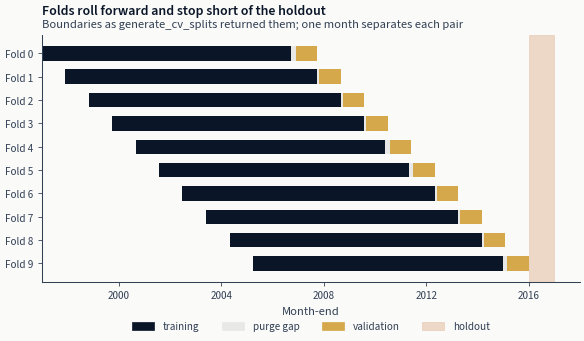

In [13]:
splits = generate_cv_splits(
    panel.select("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    outcome_horizon=OUTCOME_HORIZON,
    date_col="timestamp",
)
last_val = max(split["val_end"] for split in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert last_val < np.datetime64(HOLDOUT_START), "a fold reaches into the holdout"
print(
    f"{len(splits)} folds | training {SETUP['evaluation']['train_size']} and validation "
    f"{SETUP['evaluation']['val_size']} each, purged by labels.buffer {LABEL_BUFFER}, "
    f"outcome horizon {OUTCOME_HORIZON}\n"
    f"Validation runs {min(split['val_start'] for split in splits).date()} to "
    f"{last_val.date()}, and the holdout opens {HOLDOUT_START}"
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
ax.set_xlabel("Month-end")
add_message_title(
    ax,
    "Folds roll forward and stop short of the holdout",
    subtitle="Boundaries as generate_cv_splits returned them; one month separates each pair",
)
show_with_alt(
    fig,
    "Walk-forward fold boundaries as generate_cv_splits returned them: ten training windows each followed by its validation window, and the held-back period after the last of them.",
)

## E. What this notebook hands on

Nothing. The universe is whatever the release contains, so there is no eligibility table for a
later notebook to filter on: the panel itself already holds only what could have been sorted.

## F. What the evidence says about each setting

One row per setting: the evidence behind it, and the condition under which a reader working on
their own data would choose differently.

| Setting | Evidence | Choose differently when |
|---|---|---|
| `universe.inclusion_rule` | B.1 firms and how long they stay, B.2 firms per month-end | fewer firms are present than both sides of the sort need to fill |
| `decision.cadence` | B.3 move sizes against cost, B.4 how long a rank holds | moves stop covering the round trip, or a ranked measure changes completely inside one rebalancing interval |
| `costs.per_leg_cost_bps_range` | B.3, and the absence of any quote in the release | a cost per firm becomes measurable, or the book moves into names the range does not cover |
| `mapping.class` | B.2 firms per month-end against both sides | one side cannot be filled, or shares stop being available to borrow |
| `evaluation.n_splits` | D.1 month-ends available, D.2 fold boundaries | the folds no longer fit ahead of the holdout |

In [14]:
print(
    f"universe.inclusion_rule {SETUP['universe']['inclusion_rule']} | mapping.class "
    f"{SETUP['mapping']['class']} | decision.cadence {SETUP['decision']['cadence']}\n"
    f"firms per month-end {breadth['n_firms'].min():,} to {breadth['n_firms'].max():,}, below the "
    f"{BREADTH_FLOOR} positions to fill on "
    f"{breadth.filter(pl.col('n_firms') < BREADTH_FLOOR).height} of {len(breadth)} month-ends | "
    f"costs.per_leg_cost_bps_range {LEG_BPS} | labels.primary {PRIMARY_LABEL}\n"
    f"evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated {len(splits)}, validation "
    f"{min(split['val_start'] for split in splits).date()} to {last_val.date()}, holdout untouched"
)

universe.inclusion_rule complete_characteristic_case | mapping.class long_short_top_k_rebalance | decision.cadence monthly_month_end
firms per month-end 2,032 to 2,826, below the 100 positions to fill on 0 of 312 month-ends | costs.per_leg_cost_bps_range [5, 20] | labels.primary fwd_ret_1m
evaluation.n_splits 10, generated 10, validation 2006-11-30 to 2015-12-31, holdout untouched


The month-end cross-section runs from 2,032 to 2,826 firms, well above the 100 positions the sort
has to fill across both sides, and it is never below that on any of the 312 month-ends. Ten folds
are generated, their validation windows covering 2006-11-30 to 2015-12-31, and the holdout year
begins after the last of them.

## Key takeaways

1. **Check how a dataset is encoded before computing anything from it.** Reading a rank as a level
   or a level as a rank produces plausible numbers all the way to the end, and one assertion at
   load time is what stops it.
2. **Describe a universe by how long its members stay in it.** How much history a typical member
   has decides which statistics can be computed at all, and where the panel's rows actually come
   from is rarely where its members are.
3. **Count the universe on the dates the strategy acts**, against the positions both sides of the
   book have to fill. An average over the sample hides the thin stretches.
4. **Measure opportunity in the quantity the strategy actually earns.** A long-short sort is paid
   the spread between the firms it bought and the firms it sold, so it is that spread, not the
   market's move, that has to clear the cost of trading.
5. **Say when a cost is assumed rather than measured**, and draw the range that was declared
   rather than collapsing it to a midpoint that claims a precision the data cannot support.
6. **Compute a panel autocorrelation inside each entity, then average**, after dropping entities
   whose history has gaps.

### Known limitations

- The identifiers are stable only inside one published block, so a firm cannot be followed with
  certainty across the whole history and the providers' handling of firms that stopped trading
  cannot be audited from the release.
- The release ends in December of its final year, so the holdout is a single year - the shortest
  of any case study here, and short enough that one unusual year would dominate what it says.
- The cost is one assumed range for every firm and every month. A sort can select the smallest and
  least traded firms, where a realistic round trip sits well above the declared range, and nothing
  in this release measures how easily a given firm's shares trade.
- Spreads were far wider before decimalization in 2001 than after it, which
  `setup.yaml::costs.era_note` records without applying.

**Next**: labels at the declared monthly horizon, built on this development period.